# EDF Control Vane Design  
### Electric V-BAT-Like Tail-Sitter (EDF) — Conceptual Design Study

---

## Purpose

This design uses **four (4) deflectable flat-plate vanes** placed in the **EDF exhaust stream**.

- The vanes **re-direct the jet flow** to generate control moments about all three axes:
  - Pitch  
  - Yaw  
  - Roll  

> ⚠️ These are **not turbomachinery guide vanes**  
> They are **jet-pipe control vanes**, similar in concept to those used in **rocket nozzles**

---

## Mixing Law

**Reference frame:**  
### Aft View — Looking Upstream Into the Jet

|        |        |        |
|--------|--------|--------|
|        | **T (+z)** |        |
|        |    │    |        |
| **L (+y)** |    **+**    | **R (-y)** |
|        |    │    |        |
|        | **B (-z)** |        |


### Control Contribution Table

| Vane | Pitch | Yaw | Roll |
|------|------|------|------|
| **T** (Top)    | +d_p | 0    | +d_r |
| **B** (Bottom) | +d_p | 0    | -d_r |
| **L** (Left)   | 0    | +d_y | -d_r |
| **R** (Right)  | 0    | +d_y | +d_r |

---

## Control Interpretation

- **Pitch-up**  
  → Top (T) and Bottom (B) vanes deflect **together**

- **Yaw-right**  
  → Left (L) and Right (R) vanes deflect **together**

- **Roll-right**  
  → All four vanes deflect **differentially**

---

## Inputs

- `out/sizing_result.yaml` *(from Notebook 1)*  
- `out/airfoil.yaml` *(from Notebook 2)*  

---

## Outputs

- `out/control_vanes.yaml`  
- `out/vane_authority_curves.png`  
- `out/vane_geometry.png`  

---

In [92]:
import sys, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import yaml
 
REPO_ROOT   = Path().resolve().parents[0]
SRC_PATH    = REPO_ROOT / "src"
CONFIG_PATH = REPO_ROOT / "config"
OUT_PATH    = REPO_ROOT / "out"
sys.path.insert(0, str(SRC_PATH))
 
plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.25,
    "font.size"         : 10,
})
C = ["#2c7bb6", "#d7191c", "#1a9641", "#f68b33", "#762a83"]

*** Nothing is hard-coded here. All numbers come from first and second notebooks. 

In [93]:
'''
Re-run the sizing loop from config/ -- same pattern as NB2.
'''
 
from conceptual_design import (
    run_sizing_loop,
    Environment, Mission, Aerodynamics, Battery,
    WeightFraction, PropulsiveSystemParameters,
)
from conceptual_design.forward_flight_power import ForwardFlightParams
from conceptual_design.wing_sizing import WingStructureParams
from conceptual_design.models import RotorParams
 
env     = Environment()
mission = Mission.from_yaml(CONFIG_PATH / "mission.yaml")
aero    = Aerodynamics.from_yaml(CONFIG_PATH / "aerodynamics.yaml")
batt    = Battery.from_yaml(CONFIG_PATH / "battery.yaml")
wf      = WeightFraction.from_yaml(CONFIG_PATH / "initial_weight_fraction_estimation.yaml")
prop    = PropulsiveSystemParameters.from_yaml(CONFIG_PATH / "propulsive_system_parameters.yaml")
ff      = ForwardFlightParams.from_yaml(CONFIG_PATH / "forward_flight_params.yaml")
ws      = WingStructureParams.from_yaml(CONFIG_PATH / "wing_structure_params.yaml")
rotor   = RotorParams.from_yaml(CONFIG_PATH / "rotor.yaml")
 
result = run_sizing_loop(
    m_payload_kg = 0.5,
    mission      = mission,
    aero         = aero,
    batt         = batt,
    wf           = wf,
    prop_params  = prop,
    ff_params    = ff,
    ws_params    = ws,
    env          = env,
    D_rotor_m    = rotor.D_rotor_m,
    disk_loading = rotor.disk_loading,
)
 
# values this notebook needs
MTOW_kg      = result.m_total_kg
W_N          = MTOW_kg * env.g
V_cruise     = mission.V_cruise
D_rotor_m    = rotor.D_rotor_m
rho          = env.rho
g            = env.g
chord_mean_m = result.wing.chord_mean
 
# wing airfoil from NB2 - for section comparison only, NOT for vane design
with open(OUT_PATH / "airfoil.yaml", "r") as f:
    af = yaml.safe_load(f)
tc_wing      = af["tc_ratio"]        # 0.12
wing_af_name = af["designation"]     # NACA 2412
 
print(f"Converged MTOW : {MTOW_kg:.3f} kg  ({W_N:.2f} N)")
print(f"D_rotor        : {D_rotor_m*1e3:.1f} mm")
print(f"Wing chord     : {chord_mean_m*1e3:.1f} mm")
print(f"Wing airfoil   : {wing_af_name}  (NB2 reference only)")


Converged MTOW : 2.102 kg  (20.61 N)
D_rotor        : 280.0 mm
Wing chord     : 167.0 mm
Wing airfoil   : NACA 2412  (NB2 reference only)


# EDF Jet Parameters

---

## Actuator-Disk (Momentum) Theory

$$
v_h = \sqrt{\frac{T}{2 \rho A_{\text{disk}}}}
$$
*Induced hover velocity*

$$
V_{\text{jet}} = 2 v_h
$$
*Velocity at vane plane*

$$
q_{\text{jet}} = \frac{1}{2} \rho V_{\text{jet}}^2
$$
*Dynamic pressure on vanes*

---

## Interpretation

- $$ q_{\text{jet}} $$ drives all vane forces  
- It is typically **several times larger** than the freestream cruise dynamic pressure  

In [94]:
R_tip  = D_rotor_m / 2.0
A_disk = math.pi * R_tip**2
 
T_hover = W_N
v_h     = math.sqrt(T_hover / (2.0 * rho * A_disk))
V_jet   = 2.0 * v_h
q_jet   = 0.5 * rho * V_jet**2
mdot    = rho * A_disk * v_h
 
q_fs    = 0.5 * rho * V_cruise**2
 
print(f"R_tip   : {R_tip*1e3:.1f} mm")
print(f"v_h     : {v_h:.3f} m/s")
print(f"V_jet   : {V_jet:.3f} m/s")
print(f"q_jet   : {q_jet:.2f} Pa  ({q_jet/q_fs:.1f}x cruise q)")

R_tip   : 140.0 mm
v_h     : 11.690 m/s
V_jet   : 23.379 m/s
q_jet   : 334.79 Pa  (1.4x cruise q)


# Section 3 — Section Selection

---

## Why Not the Wing Airfoil?

The vanes and the wing operate in fundamentally different regimes:

### Comparison

| Parameter        | Wing (NB2)            | Control Vane              |
|------------------|----------------------|---------------------------|
| **Chord Re**     | 100,000 – 300,000    | 15,000 – 60,000           |
| **Operating α**  | 2–5° (fixed)         | 0–20° (full sweep)        |
| **Thickness role** | Structural spar     | Thin → less blockage      |
| **Key metric**   | L/D in cruise        | Linear \( C_l(\delta) \) over 0–20° |
| **Stall behavior** | Gentle onset       | Must be **monotonic**     |

---

### Key Insight

At $$ Re < 60000 $$, thick cambered sections (e.g. NACA 2412) develop a **laminar separation bubble** near the leading edge.

- This causes a **lift coefficient plateau or reversal**
- Occurs **well below 10°**
- This behavior is **dangerous for control surfaces**

---

## Candidate Comparison

| Section                          | Use? | Reason |
|----------------------------------|------|--------|
| **NACA 2412 (NB2 wing)**         | ❌ NO | Laminar bubble at \( Re < 60k \). Non-monotonic \( C_l(\delta) \) below 10° |
| **NACA 65-006**                  | ❌ NO | Compressor stator section. Same low-Re bubble issue |
| **Double Circular Arc (t/c = 4%)** | ⚠️ OK | No sharp LE. Only marginal improvement over flat plate |
| **Flat Plate (t/c = 2%) ← BEST** | ✅ YES | Most linear \( C_l(\delta) \) at low Re. No LE radius → no bubble. Monotonic to 15°+. Minimum blockage. Easily laser-cut CFRP |

---

## Conclusion

The **flat plate (t/c ≈ 2%)** is the optimal choice for EDF control vanes because:

- Ensures **monotonic control authority**
- Avoids **low-Re laminar separation issues**
- Minimizes **flow blockage**
- Enables **simple, low-cost manufacturing**

In [95]:
tc_vane         = 0.02
Cl_alpha_2pi    = 2.0 * math.pi
Re_correction   = 0.85             # Pelletier & Mueller 2000, Re<60k
Cl_alpha_eff    = Cl_alpha_2pi * Re_correction
delta_stall_deg = 15.0
delta_max_deg   = 20.0

# Section 4 — Vane Geometry Sizing

---

## Design Requirement

Size the vanes to meet a minimum angular acceleration:

$$
\ddot{\theta}_{\min} = 30^\circ / \text{s}^2
$$

---

## Vane Force Model

Force generated by a single vane at design deflection \( \delta_d \):

$$
F_{\text{vane}} = q_{\text{jet}} \; S_{\text{vane}} \; C_{l,\alpha}^{\text{eff}} \; \delta_d
$$

$$
S_{\text{vane}} = c_{\text{vane}} \; h_{\text{vane}}
$$

---

## Vane Geometry

The vane spans the **hub-to-tip annulus**:

$$
h_{\text{vane}} = \text{span}_{\text{frac}} \; R_{\text{tip}} \; (1 - \kappa)
$$

$$
c_{\text{vane}} = \frac{h_{\text{vane}}}{AR_{\text{vane}}}
$$

---

## Moment Arms

- **Pitch / Yaw**
  $$
  \rightarrow L_{\text{CG}}
  $$
  *(Axial distance: EDF exit plane to aircraft center of gravity)*

- **Roll**
  $$
  \rightarrow R_{\text{mid}}
  $$
  *(Mid-span radius of vane)*

---

## Moments of Inertia  
*(Slender cylinder approximation)*

$$
I_{\text{pitch}} = I_{\text{yaw}} = \frac{m}{12} \left(3 R_{\text{fus}}^2 + L_{\text{body}}^2 \right)
$$

$$
I_{\text{roll}} = \frac{m}{2} R_{\text{fus}}^2
$$

---

## Interpretation

- Required moment:
  $$
  M = I \cdot \ddot{\theta}_{\min}
  $$

- This sets the **minimum required vane force**, and therefore:
  - vane area $ S_{\text{vane}} $
  - vane span $ h_{\text{vane}} $
  - vane chord $ c_{\text{vane}} $

---


In [96]:
# configurable
kappa_hub        = 0.40
AR_vane          = 2.5
n_vanes          = 4
span_frac        = 0.85
delta_design_deg = 10.0
delta_design_rad = math.radians(delta_design_deg)
 
# derived
R_hub   = kappa_hub * R_tip
R_mid   = 0.5 * (R_tip + R_hub)
h_vane  = span_frac * (R_tip - R_hub)
c_vane  = h_vane / AR_vane
S_vane  = c_vane * h_vane
 
L_body  = 1.2 * chord_mean_m
L_CG    = 0.55 * L_body
L_roll  = R_mid
 
R_fus   = R_tip * 1.05
I_pitch = (MTOW_kg / 12.0) * (3 * R_fus**2 + L_body**2)
I_yaw   = I_pitch
I_roll  = (MTOW_kg / 2.0) * R_fus**2

In [97]:
mu_air  = 1.789e-5
nu_air  = mu_air / rho
Re_vane = V_jet * c_vane / nu_air

Cl_design  = Cl_alpha_eff * delta_design_rad
F_vane     = q_jet * S_vane * Cl_design

M_pitch_Nm = 2.0 * F_vane * L_CG
M_yaw_Nm   = 2.0 * F_vane * L_CG
M_roll_Nm  = 4.0 * F_vane * L_roll

alpha_pitch = math.degrees(M_pitch_Nm / I_pitch)
alpha_yaw   = math.degrees(M_yaw_Nm   / I_yaw)
alpha_roll  = math.degrees(M_roll_Nm  / I_roll)

ddot_min = 30.0    # deg/s^2 minimum requirement

# Deflection Limits and Thrust Loss

---

## Blockage Estimate (First-Order)

Blocked area per vane:

$$
A_{\text{block}} = S_{\text{vane}} \; \left| \sin(\delta) \right|
$$

---

## Thrust Loss Estimate

Percentage thrust loss due to vane blockage:

$$
\text{thrust}_{\text{loss},\%} =
\left(
\frac{n_{\text{vanes}} \; A_{\text{block}}}{A_{\text{disk}}}
\right) \times 100
$$

---

## Interpretation

- Thrust loss increases with:
  - vane deflection angle $ \delta $
  - vane area $ S_{\text{vane}} $
  - number of vanes $ n_{\text{vanes}} $

- For small angles:
  $$
  \sin(\delta) \approx \delta
  $$
  → thrust loss scales approximately **linearly with deflection**

- This creates a key design trade-off:
  - **More control authority** ↔ **Higher thrust loss**

---

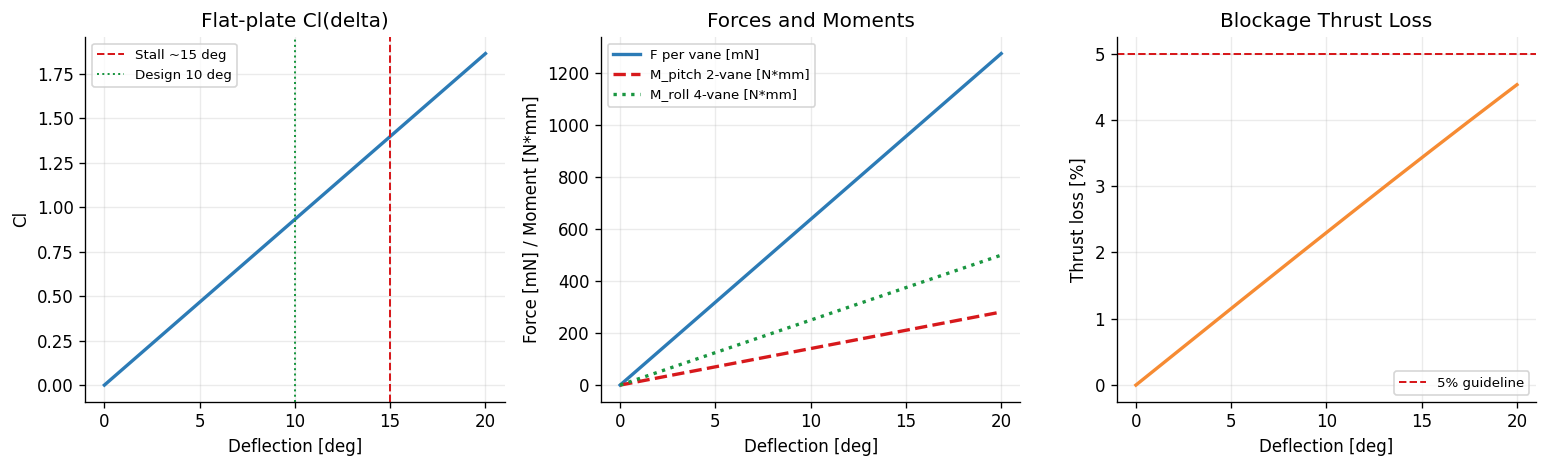

In [98]:
delta_v  = np.linspace(0, delta_max_deg, 300)
delta_r  = np.radians(delta_v)
 
Cl_v        = Cl_alpha_eff * delta_r
F_v         = q_jet * S_vane * Cl_v
M_pitch_v   = 2.0 * F_v * L_CG
M_roll_v    = 4.0 * F_v * L_roll
thrust_loss = (n_vanes * S_vane * np.abs(np.sin(delta_r)) / A_disk) * 100.0
 
# 3 subplots: Cl vs delta, forces/moments vs delta, thrust loss vs delta
 
fig, axs = plt.subplots(1, 3, figsize=(13, 4))
 
axs[0].plot(delta_v, Cl_v, color=C[0], lw=2)
axs[0].axvline(delta_stall_deg, ls="--", color=C[1], lw=1.2,
               label=f"Stall ~{delta_stall_deg:.0f} deg")
axs[0].axvline(delta_design_deg, ls=":", color=C[2], lw=1.2,
               label=f"Design {delta_design_deg:.0f} deg")
axs[0].set_xlabel("Deflection [deg]")
axs[0].set_ylabel("Cl")
axs[0].set_title("Flat-plate Cl(delta)")
axs[0].legend(fontsize=8)
 
axs[1].plot(delta_v, F_v*1e3,       color=C[0], lw=2, label="F per vane [mN]")
axs[1].plot(delta_v, M_pitch_v*1e3, color=C[1], lw=2, ls="--",
            label="M_pitch 2-vane [N*mm]")
axs[1].plot(delta_v, M_roll_v*1e3,  color=C[2], lw=2, ls=":",
            label="M_roll 4-vane [N*mm]")
axs[1].set_xlabel("Deflection [deg]")
axs[1].set_ylabel("Force [mN] / Moment [N*mm]")
axs[1].set_title("Forces and Moments")
axs[1].legend(fontsize=8)
 
axs[2].plot(delta_v, thrust_loss, color=C[3], lw=2)
axs[2].axhline(5.0, ls="--", color=C[1], lw=1.2, label="5% guideline")
axs[2].set_xlabel("Deflection [deg]")
axs[2].set_ylabel("Thrust loss [%]")
axs[2].set_title("Blockage Thrust Loss")
axs[2].legend(fontsize=8)
 
plt.tight_layout()
plt.savefig(OUT_PATH / "vane_authority_curves.png", dpi=120, bbox_inches="tight")
plt.show()


# Section 7 — Hinge Moment and Actuator Sizing

---

## Hinge Moment Model  
*(Flat plate, hinge at quarter-chord)*

$$
C_{hm} = 0.5 \; C_{l,\alpha}^{eff} \; \delta
$$
*Hinge moment coefficient (restoring, magnitude)*

$$
M_{hinge} = q_{jet} \; S_{vane} \; c_{vane} \; C_{hm}
$$

---

## Servo Torque Requirement

Including safety factor and additional margin:

$$
M_{servo} = M_{hinge,\max} \times SF \times 1.2
$$

---

## Unit Conversion

Servo specifications are typically given in **g·cm**:

$$
1 \; \text{N·m} = 10\,197 \; \text{g·cm}
$$

$$
M_{servo}^{(g\cdot cm)} = M_{servo}^{(N\dot{c} m)} \times 10\,197
$$

---

## Interpretation

- Hinge moment scales with:
  - jet dynamic pressure $ q_{jet} $
  - vane area $ S_{vane} $
  - vane chord $ c_{vane} $
  - deflection angle $ \delta $

- Design implications:
  - High $ q_{jet} $ → **very high torque demand**
  - Small geometry changes → **large actuator impact**
  - Safety factor $ SF $ is critical for reliability

---

In [99]:
C_hm_coeff  = 0.5
SF_servo    = 2.5
 
delta_max_rad = math.radians(delta_max_deg)
Ch_max        = C_hm_coeff * Cl_alpha_eff * delta_max_rad
M_hinge_max   = q_jet * S_vane * c_vane * Ch_max
 
M_servo_Nm    = M_hinge_max * SF_servo * 1.2
M_servo_gcm   = M_servo_Nm * 1e3 * 100.0 / 9.80665

# Section 8 — Control Mixing Matrix

---

## Definition

- **Rows (actuators):** T, B, L, R  
- **Columns (commands):** Pitch, Yaw, Roll  

Each element represents the **gain applied to a normalized command** in the range \([-1, +1]\).

---

## Mixing Matrix

$$
\begin{bmatrix}
T \\
B \\
L \\
R
\end{bmatrix}
=
\begin{bmatrix}
+1 &  0 & +1 \\
+1 &  0 & -1 \\
 0 & +1 & -1 \\
 0 & +1 & +1
\end{bmatrix}
\begin{bmatrix}
\delta_{pitch} \\
\delta_{yaw} \\
\delta_{roll}
\end{bmatrix}
$$

---

## Interpretation

- **Pitch control**
  - T and B move **together**

- **Yaw control**
  - L and R move **together**

- **Roll control**
  - All four vanes move **differentially**

---

## Notes

- Commands $ \delta_{pitch}, \delta_{yaw}, \delta_{roll} \in [-1, +1] $
- Matrix can be scaled by:
  - maximum deflection $ \delta_{max} $
  - or actuator limits

---

In [100]:
MIX = np.array([
    # pitch   yaw   roll
    [ +1.0,   0.0, +1.0],   # T
    [ +1.0,   0.0, -1.0],   # B
    [  0.0,  +1.0, -1.0],   # L
    [  0.0,  +1.0, +1.0],   # R
])

tests = [
    ("Pure pitch-up",   np.array([1.0, 0.0, 0.0])),
    ("Pure yaw-right",  np.array([0.0, 1.0, 0.0])),
    ("Pure roll-right", np.array([0.0, 0.0, 1.0])),
    ("Pitch + yaw",     np.array([0.5, 0.5, 0.0])),
    ("Full 3-axis",     np.array([1.0, 1.0, 1.0])),
]

print(f"{'Command':<20}  {'T':>6} {'B':>6} {'L':>6} {'R':>6}  OK?")
print("-" * 58)
for label, cmd in tests:
    d = MIX @ cmd * delta_design_deg
    ok = "OK" if all(abs(x) <= delta_max_deg for x in d) else "EXCEEDS"
    print(f"{label:<20}  {d[0]:>+6.1f} {d[1]:>+6.1f} {d[2]:>+6.1f} {d[3]:>+6.1f}  {ok}")

Command                    T      B      L      R  OK?
----------------------------------------------------------
Pure pitch-up          +10.0  +10.0   +0.0   +0.0  OK
Pure yaw-right          +0.0   +0.0  +10.0  +10.0  OK
Pure roll-right        +10.0  -10.0  -10.0  +10.0  OK
Pitch + yaw             +5.0   +5.0   +5.0   +5.0  OK
Full 3-axis            +20.0   +0.0   +0.0  +20.0  OK


# Section 9 — Geometry Visualisation

---

## Overview

This section defines the required plots for visualizing the vane geometry and deflection behavior.

---

## Plot 1 — Duct Cross-Section (Aft View)

- View: **Looking upstream into the EDF jet**
- Geometry:
  - Circular duct (radius \( R_{tip} \))
  - Hub region (optional, radius \( R_{hub} \))
- Vanes:
  - Four vanes (**T, B, L, R**) shown as **radial lines**
  - Positioned at:
    - T → \( +z \)
    - B → \( -z \)
    - L → \( +y \)
    - R → \( -y \)

### Purpose

- Verify **spatial arrangement**
- Confirm **symmetry**
- Validate **annulus coverage**

---

## Plot 2 — Vane Profile (Flat Plate)

- Section: **2D profile view**
- Geometry:
  - Flat plate with chord $ c_{vane} $
  - Thickness $ t/c \approx 2\% $

- Deflection angles:

$$
\delta \in \{0^\circ, 5^\circ, 10^\circ, 15^\circ, 20^\circ\}
$$

### Purpose

- Visualize **deflection envelope**
- Check for:
  - potential **flow blockage**
  - possible **mechanical interference**
- Illustrate **linear control region**

---

## Notes

- Plot 1 is best implemented using:
  - `matplotlib` (top view)
  - or CAD export for documentation

- Plot 2:
  - Overlay multiple deflections in a single figure
  - Use consistent pivot point (hinge at quarter-chord)

---